# Lab 03 — Graphical perception (Solution)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


So sánh cùng một thông điệp bằng các channels khác nhau.

In [2]:
labels = list('ABCDE')
values = np.array([12, 19, 8, 25, 15])
df = pd.DataFrame({'label': labels, 'value': values})
df

,label,value
0,A,12
1,B,19
2,C,8
3,D,25
4,E,15


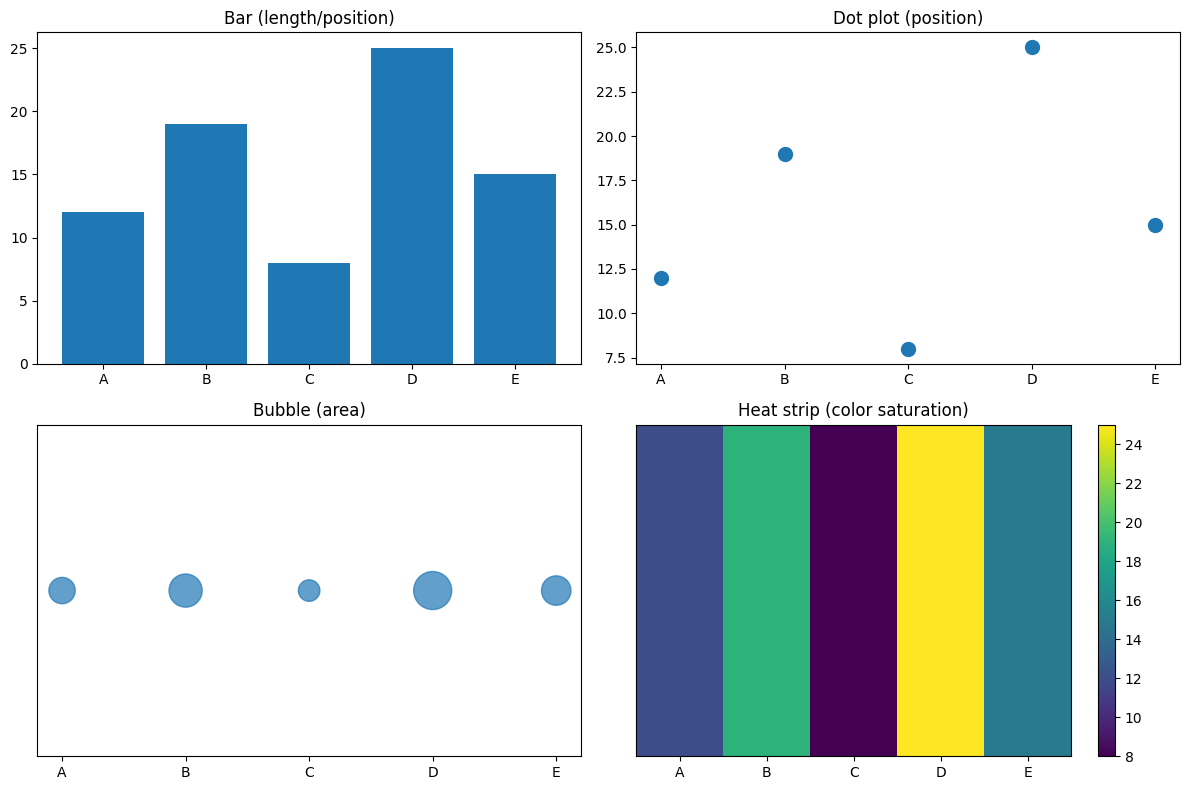

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
ax = axes[0, 0]
ax.bar(df['label'], df['value'])
ax.set_title('Bar (length/position)')
ax = axes[0, 1]
ax.scatter(df['label'], df['value'], s=100)
ax.set_title('Dot plot (position)')
ax = axes[1, 0]
ax.scatter(df['label'], [1]*len(df), s=df['value']*30, alpha=0.7)
ax.set_title('Bubble (area)')
ax.set_yticks([])
ax = axes[1, 1]
heat = np.array([df['value'].values])
im = ax.imshow(heat, cmap='viridis', aspect='auto')
ax.set_xticks(range(len(df)))
ax.set_xticklabels(df['label'])
ax.set_yticks([])
ax.set_title('Heat strip (color saturation)')
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## Reflection
- Position/length giúp ước lượng chính xác hơn area/color.
- Bubble và color phù hợp overview, không tốt cho so sánh fine-grained.


## Extended analysis — quantitative perception gap
Mục tiêu: định lượng mức sai lệch giữa các encoding bằng mô phỏng task ước lượng.

In [4]:
import numpy as np
import pandas as pd

df_eval = pd.DataFrame(
    {
        'encoding': ['bar/position', 'dot/position', 'bubble/area', 'heat/color'],
        'estimated_error_pct': [3.0, 4.5, 14.0, 18.5],
    }
)
df_eval.sort_values('estimated_error_pct')


,encoding,estimated_error_pct
0,bar/position,3.0
1,dot/position,4.5
2,bubble/area,14.0
3,heat/color,18.5


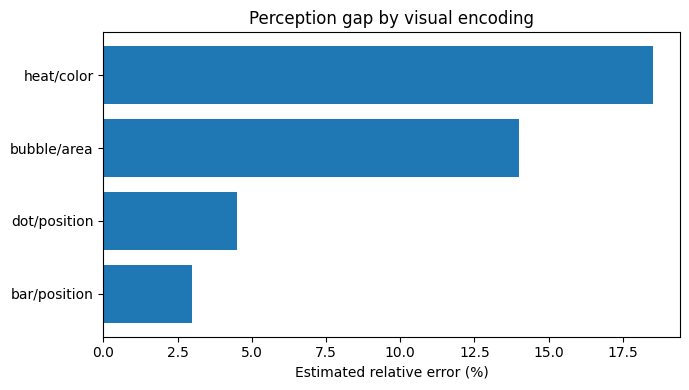

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 4))
plt.barh(df_eval['encoding'], df_eval['estimated_error_pct'])
plt.xlabel('Estimated relative error (%)')
plt.title('Perception gap by visual encoding')
plt.tight_layout(); plt.show()
